In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

from openai import OpenAI

# Part I - Customer Churn Prediction

In [2]:
dataset = pd.read_csv('./Vodafone_Customer_Churn_Sample_Dataset.csv')

In [3]:
dataset

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# EDA

In [5]:
eda = dataset.copy()
eda.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [6]:
eda['TotalCharges'] = pd.to_numeric(eda['TotalCharges'], errors='coerce')

target = 'Churn'
cat_cols = eda.select_dtypes(include=['str']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['customerID', target]]
num_cols = eda.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Categorical:', cat_cols)
print('Numeric:', num_cols)

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


### Data quality checks

- TotalCharges seems to have a very low amount of missing data. Considering the amount missing, it's a safe bet to drop these rows (<1% of the data is affected)
- Churn seems to be somewhat imbalanced, albeit not heavily. This should be considered in evaluation. (If imbalance was heavier, sub-supersampling could be considered as well)

In [7]:
# Missing values
missing = eda.isna().mean().rename('missing_ratio')
print(missing[missing > 0])

# Target balance
target_dist = eda[target].value_counts(normalize=True).rename('ratio')
print(target_dist)

TotalCharges    0.001562
Name: missing_ratio, dtype: float64
Churn
No     0.73463
Yes    0.26537
Name: ratio, dtype: float64


In [8]:
eda = eda.dropna(subset=['TotalCharges'])

### Churn-rate anaylsis of categorical variables

- What churn rate is associated with each category?
- What is the lift of each category (ratio of churn rate of category and the average churn)

In [9]:
def churn_rate_table(df, col, target='Churn'):
    t = (df.groupby(col)[target]
           .agg(count='count', churn_rate=lambda s: (s == 'Yes').mean())
           .sort_values('churn_rate', ascending=False))
    overall = (df[target] == 'Yes').mean()
    t['lift_vs_overall'] = t['churn_rate'] / overall
    return t

for c in cat_cols:
    display(churn_rate_table(eda, c, target))

,count,churn_rate,lift_vs_overall
gender,,,
Female,3483,0.269595,1.014336
Male,3549,0.262046,0.985931


,count,churn_rate,lift_vs_overall
Partner,,,
No,3639,0.329761,1.240706
Yes,3393,0.197171,0.741843


,count,churn_rate,lift_vs_overall
Dependents,,,
No,4933,0.312791,1.176859
Yes,2099,0.155312,0.584352


,count,churn_rate,lift_vs_overall
PhoneService,,,
Yes,6352,0.267475,1.006358
No,680,0.250000,0.940610


,count,churn_rate,lift_vs_overall
MultipleLines,,,
Yes,2967,0.286485,1.077881
No,3385,0.250812,0.943667
No phone service,680,0.250000,0.940610


...

,count,churn_rate,lift_vs_overall
StreamingTV,,,
No,2809,0.335351,1.261737
Yes,2703,0.301147,1.133047
No internet service,1520,0.074342,0.279708


,count,churn_rate,lift_vs_overall
StreamingMovies,,,
No,2781,0.337289,1.269029
Yes,2731,0.299524,1.126941
No internet service,1520,0.074342,0.279708


,count,churn_rate,lift_vs_overall
Contract,,,
Month-to-month,3875,0.427097,1.606926
One year,1472,0.112772,0.424297
Two year,1685,0.028487,0.107179


,count,churn_rate,lift_vs_overall
PaperlessBilling,,,
Yes,4168,0.335893,1.263775
No,2864,0.163757,0.616126


,count,churn_rate,lift_vs_overall
PaymentMethod,,,
Electronic check,2365,0.452854,1.703836
Mailed check,1604,0.192020,0.722464
Bank transfer (automatic),1542,0.167315,0.629513
Credit card (automatic),1521,0.152531,0.573890


### Hypothesis tests

- Is there an association between categorical columns and churn?
    - We're not measuring the strength of this association (Potential TODO)

- Results show similar results with churn tables above, features such as gender have less significance

In [10]:
rows = []
for c in cat_cols:
    cont = pd.crosstab(eda[c], eda[target])
    chi2, p, dof, exp = chi2_contingency(cont)
    rows.append({
        'feature': c,
        'chi2_stat': chi2,
        'chi2_pvalue': p,
        'levels': eda[c].nunique()
    })

assoc = pd.DataFrame(rows).sort_values('chi2_pvalue')
display(assoc)

,feature,chi2_stat,chi2_pvalue,levels
12,Contract,1179.545829,7.326182e-257,3
6,OnlineSecurity,846.677389,1.400687e-184,3
9,TechSupport,824.925564,7.407808e-180,3
5,InternetService,728.695614,5.831199e-159,3
14,PaymentMethod,645.429900,1.426310e-139,4
7,OnlineBackup,599.175185,7.776099e-131,3
8,DeviceProtection,555.880327,1.959389e-121,3
11,StreamingMovies,374.268432,5.353560e-82,3
10,StreamingTV,372.456502,1.324641e-81,3
13,PaperlessBilling,256.874908,8.236203e-58,2


### Correlation of numerical features and churn

- Simple measure of linear relationship between churn and numerical values
- Features show some (it might be a bit weak) correlation with target, I'll keep these numerical features for now, although the 'SeniorCitizen' feature might need additional analysis

In [11]:
eda['Churn_bin'] = (eda['Churn'] == 'Yes').astype(int)

numerical_corrs = []
for c in num_cols:
    corr = eda[[c, 'Churn_bin']].corr().iloc[0, 1]
    numerical_corrs.append({'feature': c, 'corr': corr})

numerical_corrs = pd.DataFrame(numerical_corrs).sort_values('corr', key=lambda s: s.abs(), ascending=False)
display(numerical_corrs)

,feature,corr
1,tenure,-0.354049
3,TotalCharges,-0.199484
2,MonthlyCharges,0.192858
0,SeniorCitizen,0.150541


### Feature selection

- Keep categorical columns with enough significance (this also reflect the calculated lift, i.e. features with lift further away from 1.0)
- Keep all numerical columns for now
    - A potential todo is looking at multi-colinearity e.g. between Monthly and Total Charges

In [12]:
p_th = 0.05

cat_keep = assoc.loc[(assoc['chi2_pvalue'] < p_th), 'feature'].tolist()

num_keep = numerical_corrs.loc[numerical_corrs['corr'].abs() >= 0.05, 'feature'].tolist()

print('Categorical to keep:', cat_keep)
print('Numeric to keep:', num_keep)

Categorical to keep: ['Contract', 'OnlineSecurity', 'TechSupport', 'InternetService', 'PaymentMethod', 'OnlineBackup', 'DeviceProtection', 'StreamingMovies', 'StreamingTV', 'PaperlessBilling', 'Dependents', 'Partner', 'MultipleLines']
Numeric to keep: ['tenure', 'TotalCharges', 'MonthlyCharges', 'SeniorCitizen']


# Data Transformation

### Preprocess dataset
- Transform TotalCharges into a numerical column, and drop NaN values as explained in EDA
- Encode binary categories into binary numerical columns (0/1)
- Encode nominal categories into one-hot encoded categories

In [13]:
def preprocess_dataset(dataset, binary_cols, nominal_cols, num_cols):
    dataset_encoded = dataset.copy()

    # Select only the desired columns before encoding
    dataset_encoded = dataset_encoded[binary_cols + nominal_cols + num_cols]

    binary_mapping = {'Yes': 1, 'No': 0}
    for col in binary_cols:
        dataset_encoded[col] = dataset_encoded[col].map(binary_mapping)
        
    dataset_encoded = pd.get_dummies(dataset_encoded, columns=nominal_cols)
    
    dataset_encoded['TotalCharges'] = pd.to_numeric(dataset_encoded['TotalCharges'], errors='coerce')
    dataset_encoded.dropna(subset=['TotalCharges'], inplace=True)
    
    return dataset_encoded

In [14]:
# Keep features based on EDA
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
binary_cols = [col for col in binary_cols if col in cat_keep or col == target]

nominal_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
                'Contract', 'PaymentMethod']

nominal_cols = [col for col in nominal_cols if col in cat_keep]

numerical_cols = num_keep
dataset_encoded = preprocess_dataset(dataset, binary_cols, nominal_cols, numerical_cols)

# Preparing dataset, modeling

- train-test split: considering imbalance used stratified split to keep churn ratio in both sets

In [15]:
X = dataset_encoded.drop(columns=[target])
y = dataset_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

- Train (and tune) two classification models, a simple logistic regression and a random forest, within a basic hyperparameter space, a TODO would be to measure and plot the impact of each dimension of the parameter sets, and tune better accordingly.

In [16]:
# Spaces for tuning
search_spaces = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression())
        ]),
        'params': {
            'model__class_weight': [None, 'balanced'],
            'model__max_iter': [1000, 2000]
        },
        'n_iter': 10
    },
    'Random Forest': {
        'pipeline': Pipeline([
            ('scaler', 'passthrough'),
            ('model', RandomForestClassifier())
        ]),
        'params': {
            'model__n_estimators': [200, 400, 800],
            'model__max_depth': [None, 8, 16],
            'model__min_samples_leaf': [1, 2, 4],
            'model__class_weight': [None, 'balanced']
        },
        'n_iter': 10
    }
}


- For evaluation, we have to consider the inbalance present in the dataset, so while we take a look at e.g. ROC-AUC, the Precision-Recall curve captures the inbalance better, as we want to minimize false negatives (seen in recall) while keeping false positives at an acceptable level (seen in precision). See the 'Questions' segment below for more elaboration on this.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True) # Considering the imbalance
results = {}

for name, spec in search_spaces.items():
    search = GridSearchCV(
        estimator=spec['pipeline'],
        param_grid=spec['params'],
        scoring='average_precision',
        cv=cv,
        n_jobs=-1,
        refit=True
    )
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    y_prob = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)

    roc = roc_auc_score(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    results[name] = {
        'model': best_model,
        'roc_auc': roc,
        'ap': ap,
        'precision_curve': precision,
        'recall_curve': recall,
        'fpr': fpr,
        'tpr': tpr
    }

    print(name)
    print('Best params:', search.best_params_)
    print(f'Test ROC-AUC: {roc:.3f}')
    print(f'Test PR-AUC:  {ap:.3f}')
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Logistic Regression
Best params: {'model__class_weight': None, 'model__max_iter': 1000}
Test ROC-AUC: 0.852
Test PR-AUC:  0.668
              precision    recall  f1-score   support

    No Churn       0.85      0.91      0.88      1291
       Churn       0.68      0.55      0.61       467

    accuracy                           0.81      1758
   macro avg       0.76      0.73      0.74      1758
weighted avg       0.80      0.81      0.80      1758

Random Forest
Best params: {'model__class_weight': None, 'model__max_depth': 8, 'model__min_samples_leaf': 4, 'model__n_estimators': 400}
Test ROC-AUC: 0.853
Test PR-AUC:  0.680
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.88      1291
       Churn       0.69      0.52      0.59       467

    accuracy                           0.81      1758
   macro avg       0.76      0.72      0.73      1758
weighted avg       0.80      0.81      0.80      1758



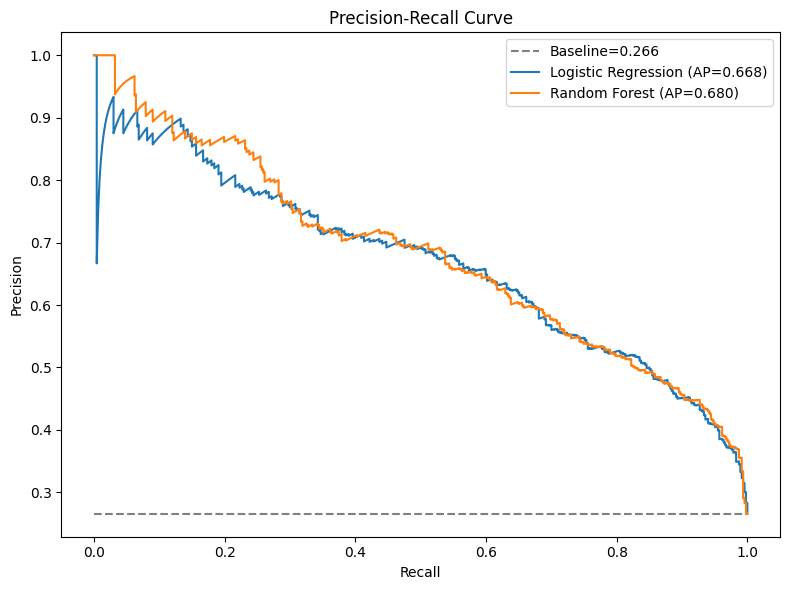

In [18]:
# Precision-Recall plot
plt.figure(figsize=(8, 6))
baseline = y_test.mean()
plt.hlines(baseline, 0, 1, colors='gray', linestyles='--', label=f'Baseline={baseline:.3f}')

for name, res in results.items():
    plt.plot(res['recall_curve'], res['precision_curve'], label=f'{name} (AP={res['ap']:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

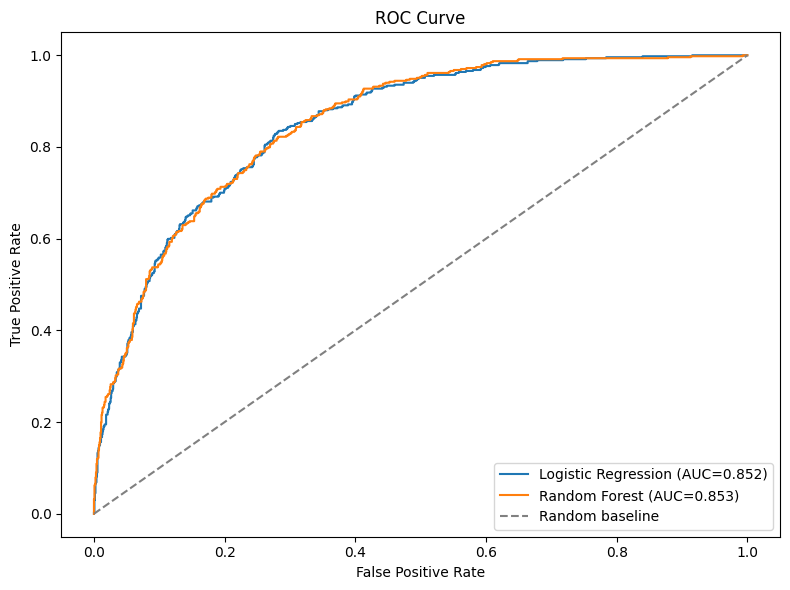

In [19]:
# ROC plot
plt.figure(figsize=(8, 6))
for name, res in results.items():
    plt.plot(res['fpr'], res['tpr'], label=f'{name} (AUC={res['roc_auc']:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

# Questions

## How well can we classify churn? Which algorithms are best to use?
- Churn classification is a 'classical' inbalanced binary classification problem, where what we want to use/optimize depends on the business interest.
- Specifically, the clash that can happen is
    - We are most interested in classifying actual leaving customers correctly, before they leave (True positives) and minimizing classifying who do leave as non-leavers (False negatie)
    - But we also need to consider how many emails we actually want to write, so we need to keep predicting customers leaving (when they won't) at an acceptable level, as mass-sending emails cost funds, and also decreaase the reputation of the company (e.g. higher chance of being categorized as spam etc.)
- Both tested algorithms show viability to use for this classification task, but need further work. Random Forest being the more balanced (overall best performing) of the two, while Logistic Regression performing the best at capturing actual churners

## Which factors are influencing churn prediction and in what direction?

- tenure

Longer tenure strongly reduces churn in Logistic Regression and is the most important feature in Random Forest.

- Contract_Month-to-month

This is one of the strongest churn-increasing features in LR and the second most important feature in RF. I.e. customers on short plans are easier to lose.

- Contract_Two year

Longer contracts seem to protect against churn.

- TechSupport_No and OnlineSecurity_No

These show up as churn-increasing in LR and important in RF. That is a strong signal that lack of support/security services is associated with higher churn risk.

- InternetService_Fiber optic

Positive in LR and important in RF. This dataset often shows fiber customers churning more, possibly because they face higher prices or different service expectations.

- Charges

There is a high chance of TotalCharges, MonthlyCharges having a large colleration with tenure, while the models found these important I would not make suggestions based off of them without further analysis. TotalCharges for example might be capturing “high spending conditional on tenure,” not simply “higher total charges cause churn.”




In [20]:
# Direction from Logistic Regression coefficients
lr = results['Logistic Regression']['model']
coef = lr.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({'feature': X.columns, 'coef': coef})
coef_df = coef_df.sort_values('coef', ascending=False)

print('Top factors increasing churn risk:')
display(coef_df.head(10))

print('Top factors decreasing churn risk:')
display(coef_df.tail(10))

Top factors increasing churn risk:


,feature,coef
4,TotalCharges,0.708249
11,InternetService_Fiber optic,0.379994
31,Contract_Month-to-month,0.275429
2,PaperlessBilling,0.177321
30,StreamingMovies_Yes,0.164718
27,StreamingTV_Yes,0.161537
36,PaymentMethod_Electronic check,0.133752
13,OnlineSecurity_No,0.127475
9,MultipleLines_Yes,0.105113
22,TechSupport_No,0.092438


Top factors decreasing churn risk:


,feature,coef
17,OnlineBackup_No internet service,-0.107731
26,StreamingTV_No internet service,-0.107731
23,TechSupport_No internet service,-0.107731
12,InternetService_No,-0.107731
14,OnlineSecurity_No internet service,-0.107731
20,DeviceProtection_No internet service,-0.107731
10,InternetService_DSL,-0.302347
33,Contract_Two year,-0.343627
5,MonthlyCharges,-0.871773
3,tenure,-1.441931


In [21]:
# Random Forest feature importance
rf = results['Random Forest']['model']
imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

display(imp_df.head(15))

,feature,importance
3,tenure,0.156424
4,TotalCharges,0.126161
31,Contract_Month-to-month,0.123120
13,OnlineSecurity_No,0.076626
5,MonthlyCharges,0.071436
11,InternetService_Fiber optic,0.056985
36,PaymentMethod_Electronic check,0.051918
33,Contract_Two year,0.044841
22,TechSupport_No,0.042978
10,InternetService_DSL,0.023142


# Part II - Generate an email using Large Language Models, in the style of our client

- Score customers based on risk level

In [22]:
all_probs = results['Logistic Regression']['model'].predict_proba(X)[:, 1]

customer_base = dataset.loc[X.index].copy()

scored_customers = customer_base.copy()
scored_customers["churn_probability"] = all_probs

# TODO: Define risk levels based on churn probability thresholds
scored_customers["risk_level"] = pd.cut(
    scored_customers["churn_probability"],
    bins=[0.0, 0.4, 0.6, 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

display(scored_customers[["customerID", "churn_probability", "risk_level"]].head())

,customerID,churn_probability,risk_level
0,7590-VHVEG,0.638640,High
1,5575-GNVDE,0.043989,Low
2,3668-QPYBK,0.299055,Low
3,7795-CFOCW,0.027147,Low
4,9237-HQITU,0.699123,High


- Create some customer segments for customer-specific prompting

In [23]:
def assign_segment(row):
    # Segment A: Price-sensitive / likely value-seeking
    if (row.get("Contract") == "Month-to-month") and (float(row.get("MonthlyCharges", 0)) >= 70):
        return "price_sensitive_monthly"

    # Segment B: Service-friction risk
    if (row.get("TechSupport") == "No") or (row.get("OnlineSecurity") == "No"):
        return "service_support_gap"


In [24]:
scored_customers["segment"] = scored_customers.apply(assign_segment, axis=1)
scored_customers["segment"].value_counts()

segment
service_support_gap        2427
price_sensitive_monthly    2104
Name: count, dtype: int64

- Select some high risk customers as an example

In [25]:
at_risk = scored_customers[scored_customers["risk_level"] == "High"].copy()
most_at_risk_customer = at_risk.sort_values("churn_probability", ascending=False).iloc[0]
most_at_risk_customer

customerID                        9497-QCMMS
gender                                  Male
SeniorCitizen                              1
Partner                                   No
Dependents                                No
tenure                                     1
PhoneService                             Yes
MultipleLines                            Yes
InternetService                  Fiber optic
OnlineSecurity                            No
OnlineBackup                              No
DeviceProtection                          No
TechSupport                               No
StreamingTV                              Yes
StreamingMovies                          Yes
Contract                      Month-to-month
PaperlessBilling                         Yes
PaymentMethod               Electronic check
MonthlyCharges                         93.55
TotalCharges                           93.55
Churn                                    Yes
churn_probability                    0.84668
risk_level

In [26]:
client = OpenAI(api_key="YOUR_API_KEY")

def make_segment_prompt(row):
    first_name = "Customer name"  # no name field in dataset

    common_header = f"""
You are writing a Vodafone customer retention email.

Tone requirements:
- Friendly and approachable
- Clear and concise
- Positive and reassuring
- Professional and trustworthy
- Avoid technical jargon
- Keep email under 170 words

Required structure:
1) Subject line
2) Greeting with customer first name
3) 1-2 sentence intro
4) 3 bullet points with benefits/offers
5) Clear call to action
6) Warm closing and Vodafone Customer Care Team signature

Customer details:
- Name: {first_name}
- Customer ID: {row.get('customerID', 'N/A')}
- Risk level: {row.get('risk_level', 'High')}
- Churn probability: {row.get('churn_probability', 0):.2f}
- Tenure (months): {row.get('tenure', 'N/A')}
- Contract: {row.get('Contract', 'N/A')}
- Internet service: {row.get('InternetService', 'N/A')}
- Tech support: {row.get('TechSupport', 'N/A')}
- Online security: {row.get('OnlineSecurity', 'N/A')}
- Payment method: {row.get('PaymentMethod', 'N/A')}
- Monthly charges: {row.get('MonthlyCharges', 'N/A')}

Do not mention model predictions or churn scoring explicitly.
"""

    segment = row.get("segment", "service_support_gap")

    if segment == "price_sensitive_monthly":
        segment_instruction = """
Segment objective: Price-sensitive customer on flexible monthly plan.
Focus:
- Emphasize value and bill optimization.
- Offer clear savings and flexible options.
- Keep reassurance around control and transparency.
"""

    elif segment == "service_support_gap":
        segment_instruction = """
Segment objective: Customer with support/security gaps.
Focus:
- Emphasize reliability, help, and peace of mind.
- Highlight priority support and service quality.
- Reassure that Vodafone can simplify and improve their experience.
"""

    else:
        segment_instruction = """
Segment objective: General retention.
Focus on value, support, and customer appreciation.
"""

    return common_header + "\n" + segment_instruction

In [27]:
examples = (
    scored_customers.sort_values("churn_probability", ascending=False)
    .groupby("segment", as_index=False)
    .head(1)
    .copy()
)

examples[["customerID", "segment", "churn_probability", "Contract", "MonthlyCharges", "TechSupport", "tenure"]]

,customerID,segment,churn_probability,Contract,MonthlyCharges,TechSupport,tenure
1976,9497-QCMMS,price_sensitive_monthly,0.846680,Month-to-month,93.55,No,1
1325,7206-GZCDC,service_support_gap,0.750748,Month-to-month,69.25,No,1


In [28]:
example_prompts = {}
for _, row in examples.iterrows():
    seg = row["segment"]
    example_prompts[seg] = make_segment_prompt(row)

for seg, p in example_prompts.items():
    print(f"\n\n===== SEGMENT: {seg} =====\n")
    print(p)



===== SEGMENT: price_sensitive_monthly =====


You are writing a Vodafone customer retention email.

Tone requirements:
- Friendly and approachable
- Clear and concise
- Positive and reassuring
- Professional and trustworthy
- Avoid technical jargon
- Keep email under 170 words

Required structure:
1) Subject line
2) Greeting with customer first name
3) 1-2 sentence intro
4) 3 bullet points with benefits/offers
5) Clear call to action
6) Warm closing and Vodafone Customer Care Team signature

Customer details:
- Name: Customer name
- Customer ID: 9497-QCMMS
- Risk level: High
- Churn probability: 0.85
- Tenure (months): 1
- Contract: Month-to-month
- Internet service: Fiber optic
- Tech support: No
- Online security: No
- Payment method: Electronic check
- Monthly charges: 93.55

Do not mention model predictions or churn scoring explicitly.


Segment objective: Price-sensitive customer on flexible monthly plan.
Focus:
- Emphasize value and bill optimization.
- Offer clear savings and

In [29]:
client = OpenAI(api_key='API_KEY_HERE')

def generate_email(prompt, model="gpt-4.1-mini", temperature=0.6):
    resp = client.responses.create(
        model=model,
        input=prompt,
        temperature=temperature
    )
    return resp.output_text.strip()

- Emails were generated through interface, not API, but above example shows how API would be used. Below are two emails for two different segments

In [30]:
#email_text = generate_email(client, prompt)

email_text_saving_plan = f"""
Subject: Let’s help you save more on your plan

Hi Customer name,

We’re really glad you chose Vodafone. We want to make sure you’re getting great value and full control over your monthly costs.

- Enjoy a personalised plan review to help reduce your monthly bill
- Access flexible options—adjust your plan anytime with no long-term commitment
- Add affordable support and security features only when you need them

You’re always in control, and we’re here to keep things simple and transparent. Just reply to this email or sign in to your account to explore your options and start saving today.

Warm regards,
Vodafone Customer Care Team"""

email_text_support_gap = f"""
Subject: We’re here to make your connection even smoother

Hi Customer name,

Welcome to Vodafone—we’re glad to have you with us. We’d love to help make your experience simpler, more reliable, and worry-free from the start.

- Get access to priority tech support whenever you need quick, friendly help
- Add online security features to keep your connection safe and protected
- Enjoy a reliable fiber connection backed by our dedicated service team

We’re here to give you peace of mind and make things easy every step of the way. Simply reply to this email or log in to your account to explore these options today.

Warm regards,
Vodafone Customer Care Team
"""

In [31]:
print(email_text_saving_plan)
print(email_text_support_gap)


Subject: Let’s help you save more on your plan

Hi Customer name,

We’re really glad you chose Vodafone. We want to make sure you’re getting great value and full control over your monthly costs.

- Enjoy a personalised plan review to help reduce your monthly bill
- Access flexible options—adjust your plan anytime with no long-term commitment
- Add affordable support and security features only when you need them

You’re always in control, and we’re here to keep things simple and transparent. Just reply to this email or sign in to your account to explore your options and start saving today.

Warm regards,
Vodafone Customer Care Team

Subject: We’re here to make your connection even smoother

Hi Customer name,

Welcome to Vodafone—we’re glad to have you with us. We’d love to help make your experience simpler, more reliable, and worry-free from the start.

- Get access to priority tech support whenever you need quick, friendly help
- Add online security features to keep your connection sa

# Questions

### How do you ensure the generated content adheres to the brand guidelines of the client?

- Manual:
    - Start with sampled review by marketing/brand team.
    - Approve templates and prompt versions before full rollout.
- Automated:
    - Validate after generation (using another model for example):
        - Run an automatic checklist per email
    - If failed, auto-regenerate with feedback (for example: “too long”, “missing bullet points”, “tone too formal”).
    - Log and review failed occurances

### How could this concept scale across different customer journeys, phases or segments?

- Per-segment templates, as seen above
- Customer journey would need to be included as a feature, together with a decision layer that chooses the type of campaign we'd like to include the user in, and a layer containing a separate prompting strategy for each customer segment